# Descriptive distributions: success vs failure on net-zero-by-2070

For each pathway variable selected in the build step, plot its distribution split by
`success_nz2070` / `failure_nz2070`, and then by the refined `desired_success` region
(net zero by 2070 *and* below-median cumulative CCS reliance). Purpose: build intuition
before any PRIM/CART run - see which variables visibly separate the groups and which don't.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
PALETTE = {"Success (NZ \u2264 2070)": "#2a9d8f", "Failure (NZ > 2070 or never)": "#e76f51"}

In [2]:
df = pd.read_csv("data_for_scenariodiscovery_full.csv")
df["success_nz2070"] = df["success_nz2070"].astype(bool)
df["low_ccs_reliance"] = df["low_ccs_reliance"].astype(bool)
df["desired_success"] = df["desired_success"].astype(bool)

df["group"] = np.where(
    df["success_nz2070"], "Success (NZ ≤ 2070)", "Failure (NZ > 2070 or never)"
)

# Three-way split that separates the two ways to reach net zero (equifinality):
# low-CCS-reliance "desired" successes vs high-CCS-reliance successes vs outright failures.
CAT_DESIRED = "Desired (NZ≤2070 & low CCS)"
CAT_HIGH_CCS = "NZ≤2070 but high CCS reliance"
CAT_FAILURE = "Failure (no NZ by 2070)"

df["category"] = np.where(
    df["desired_success"], CAT_DESIRED,
    np.where(df["success_nz2070"], CAT_HIGH_CCS, CAT_FAILURE),
)
CAT_PALETTE = {CAT_DESIRED: "#2a9d8f", CAT_HIGH_CCS: "#f4a261", CAT_FAILURE: "#e76f51"}

print(df["group"].value_counts())
print()
print(df["category"].value_counts())
df.shape

group
Failure (NZ > 2070 or never)    1102
Success (NZ ≤ 2070)              497
Name: count, dtype: int64

category
Failure (no NZ by 2070)          1102
Desired (NZ≤2070 & low CCS)       372
NZ≤2070 but high CCS reliance     125
Name: count, dtype: int64


/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/259364183.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["group"] = np.where(
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/259364183.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["category"] = np.where(


(1599, 341)

In [3]:
VARS_OF_INTEREST = [
    "Emissions|CO2",
    "Primary Energy",
    "Primary Energy|Fossil",
    "Primary Energy|Non-Biomass Renewables",
    "Primary Energy|Biomass",
    "Primary Energy|Nuclear",
    "Final Energy",
    "Final Energy|Electricity",
    "Carbon Capture|Geological Storage",
    "Carbon Removal|Land Use",
    "GDP|PPP",
    "Population",
    "GDP per capita|PPP",
]
SNAPSHOT_YEAR = 2050

for v in VARS_OF_INTEREST:
    col = f"{v}|{SNAPSHOT_YEAR}"
    print(f"{col:55s} missing={df[col].isna().mean():5.1%}  n={df[col].notna().sum()}")

Emissions|CO2|2050                                      missing= 0.9%  n=1584
Primary Energy|2050                                     missing= 1.1%  n=1582
Primary Energy|Fossil|2050                              missing= 1.5%  n=1575
Primary Energy|Non-Biomass Renewables|2050              missing= 8.7%  n=1460
Primary Energy|Biomass|2050                             missing= 1.3%  n=1578
Primary Energy|Nuclear|2050                             missing= 1.0%  n=1583
Final Energy|2050                                       missing= 1.4%  n=1576
Final Energy|Electricity|2050                           missing= 2.6%  n=1558
Carbon Capture|Geological Storage|2050                  missing= 5.4%  n=1513
Carbon Removal|Land Use|2050                            missing=35.9%  n=1025
GDP|PPP|2050                                            missing=14.5%  n=1367
Population|2050                                         missing= 9.3%  n=1451
GDP per capita|PPP|2050                                 missing=

## Distribution of each variable at 2050, split by outcome

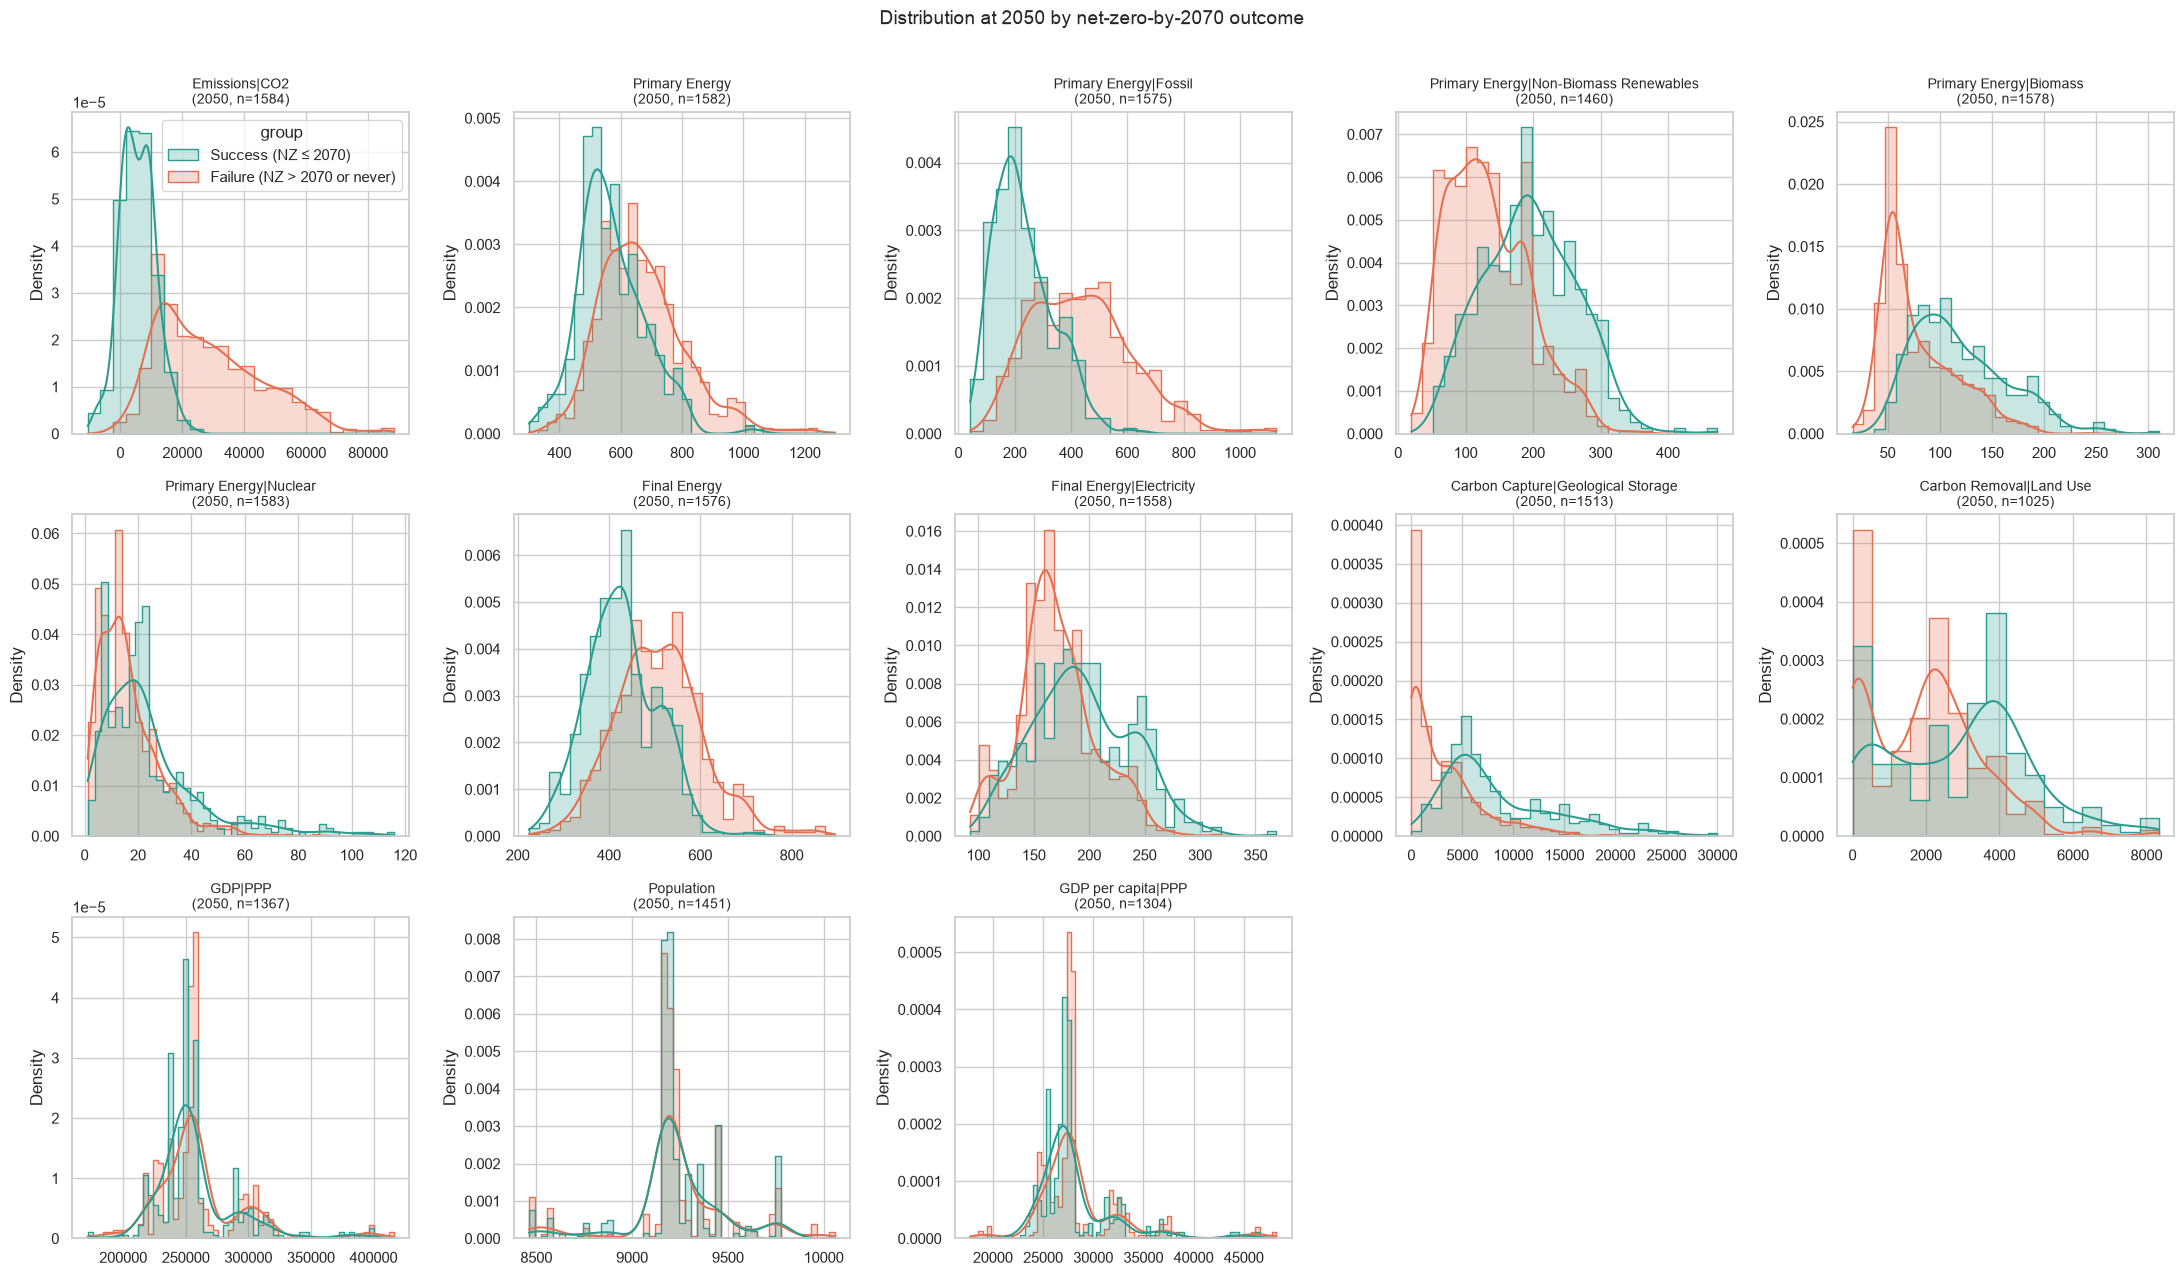

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for ax, var in zip(axes, VARS_OF_INTEREST):
    col = f"{var}|{SNAPSHOT_YEAR}"
    n_obs = df[col].notna().sum()
    sns.histplot(
        data=df, x=col, hue="group", palette=PALETTE, element="step", stat="density",
        common_norm=False, kde=True, ax=ax, legend=(var == VARS_OF_INTEREST[0]),
    )
    ax.set_title(f"{var}\n({SNAPSHOT_YEAR}, n={n_obs})", fontsize=10)
    ax.set_xlabel("")
for ax in axes[len(VARS_OF_INTEREST):]:
    ax.set_visible(False)

fig.suptitle(f"Distribution at {SNAPSHOT_YEAR} by net-zero-by-2070 outcome", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("distributions_2050.png", dpi=150)
plt.show()

## Same comparison as box/strip plots (robust to the long tails above)

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/2458009249.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Success", "Failure"])
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/2458009249.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Success", "Failure"])
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/2458009249.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Success", "Failure"])
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/2458009249.py:16: UserWarning: set_ticklabels() should only

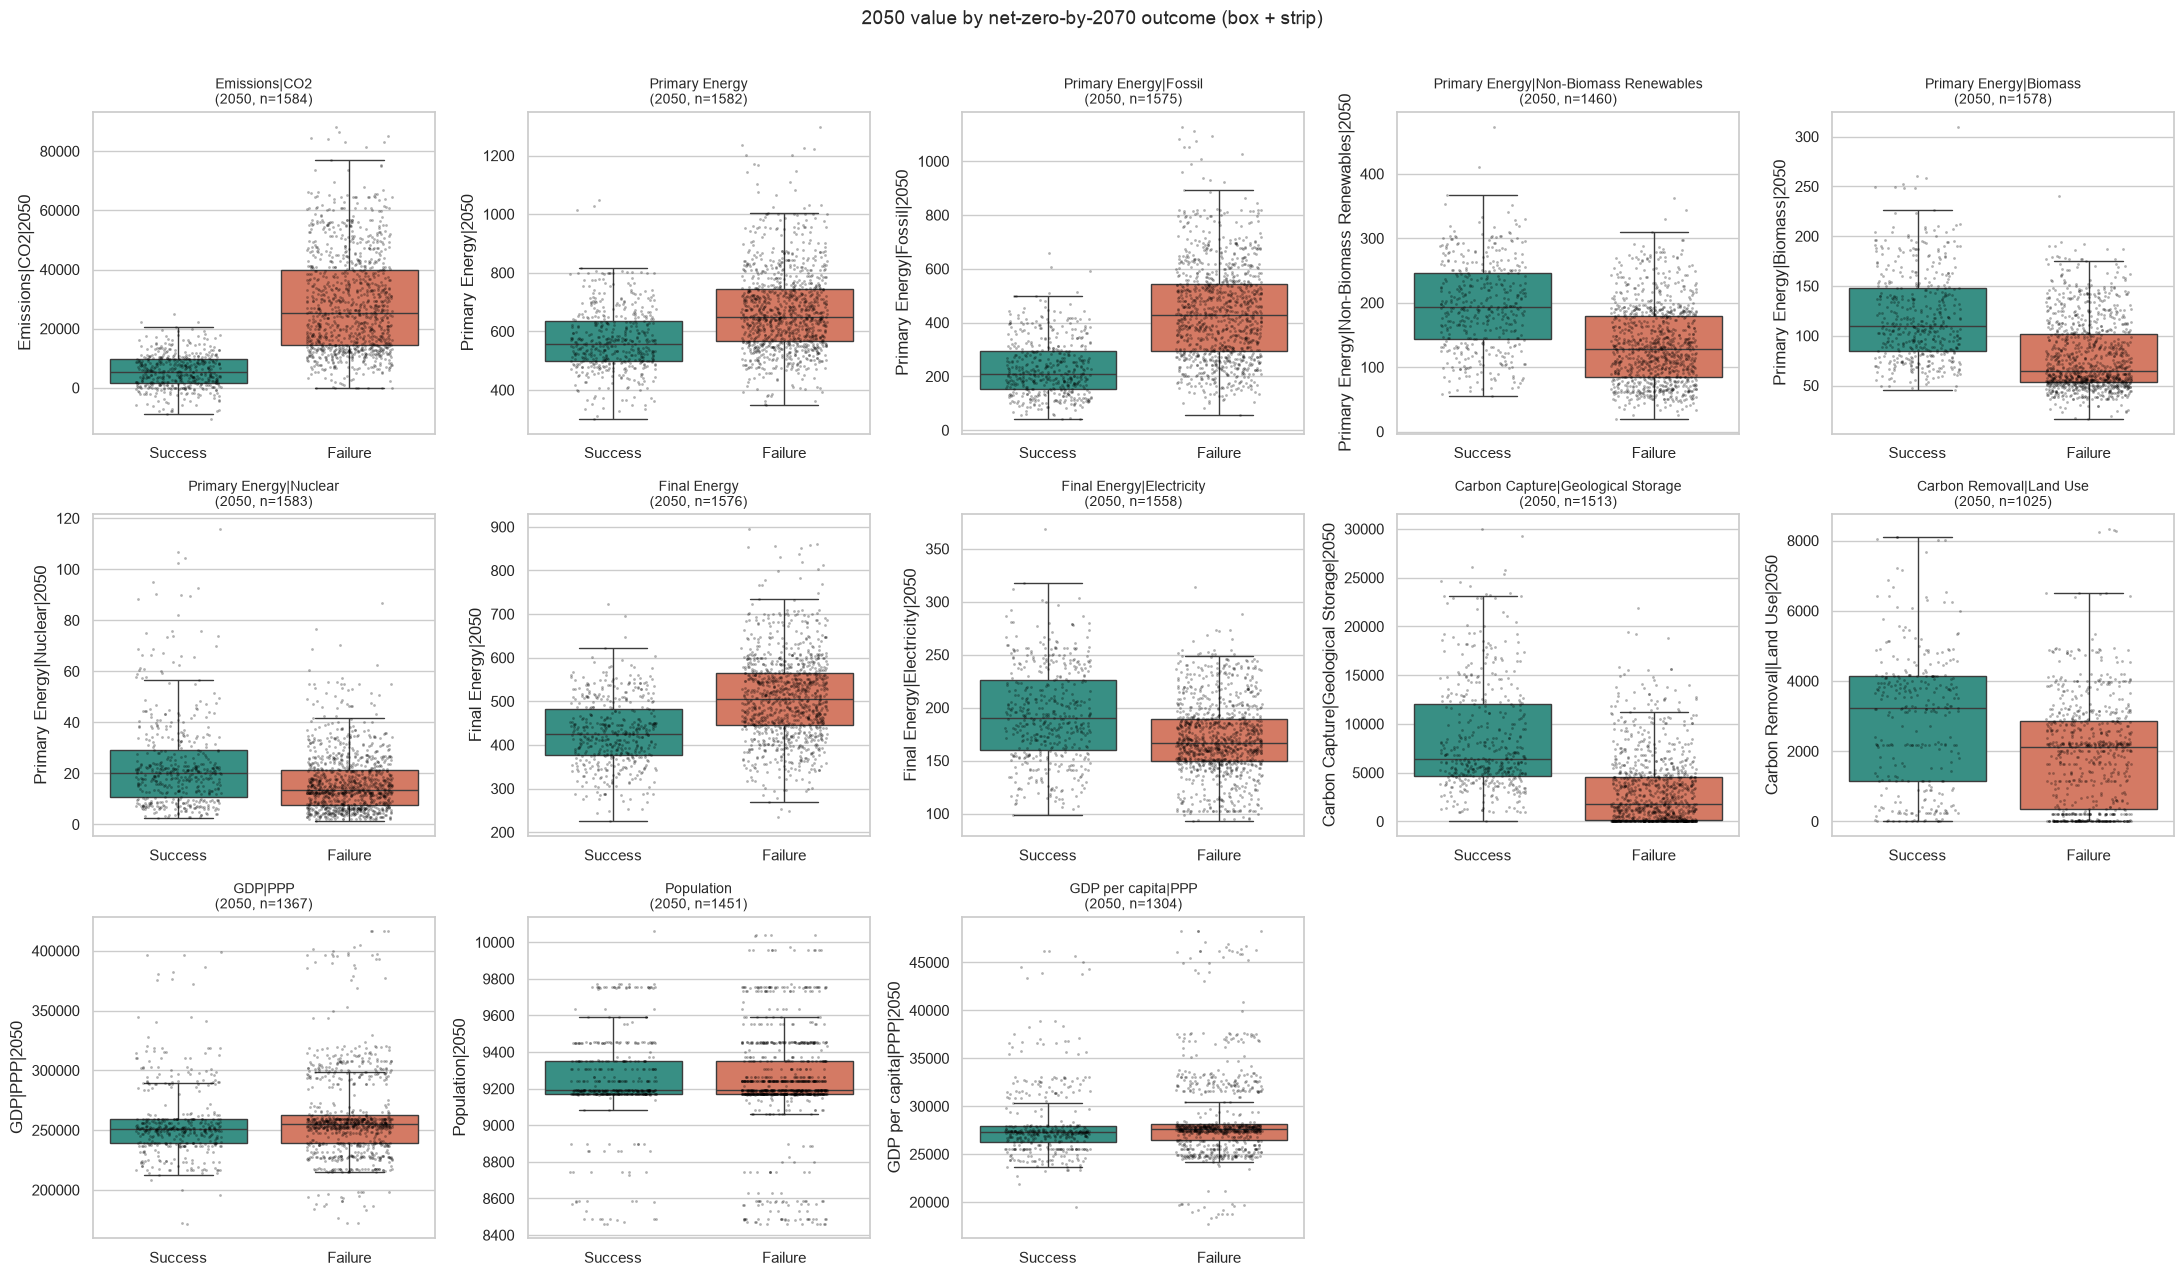

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for ax, var in zip(axes, VARS_OF_INTEREST):
    col = f"{var}|{SNAPSHOT_YEAR}"
    n_obs = df[col].notna().sum()
    sns.boxplot(
        data=df, x="group", y=col, hue="group", palette=PALETTE, ax=ax, legend=False,
        showfliers=False,
    )
    sns.stripplot(
        data=df, x="group", y=col, ax=ax, color="black", size=2, alpha=0.3, jitter=0.25,
    )
    ax.set_title(f"{var}\n({SNAPSHOT_YEAR}, n={n_obs})", fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["Success", "Failure"])
for ax in axes[len(VARS_OF_INTEREST):]:
    ax.set_visible(False)

fig.suptitle(f"{SNAPSHOT_YEAR} value by net-zero-by-2070 outcome (box + strip)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("boxplots_2050.png", dpi=150)
plt.show()

## CO2 trajectories: median + interquartile band, success vs failure

Unlike the snapshots above, this uses the full 2010-2100 trajectory already pivoted into the dataset.

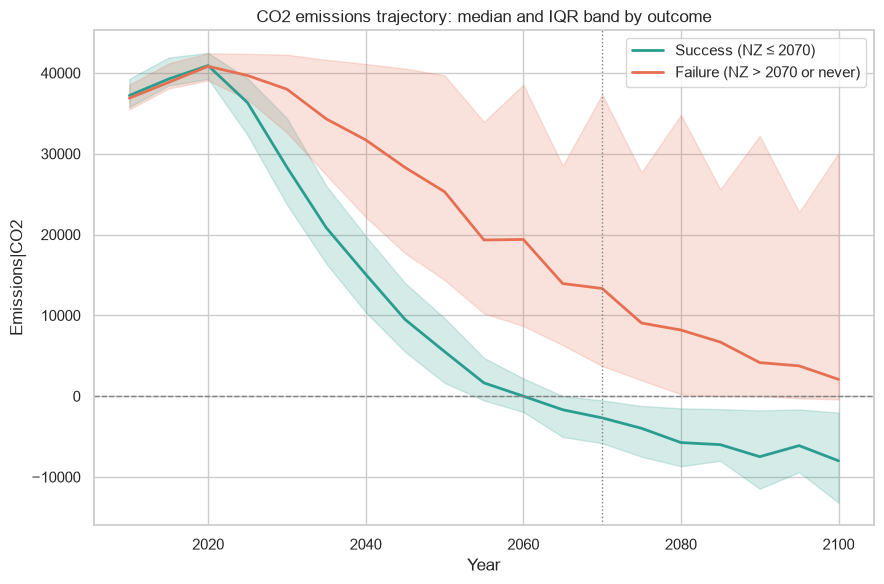

In [6]:
co2_cols = sorted(
    [c for c in df.columns if c.startswith("Emissions|CO2|")],
    key=lambda c: int(c.split("|")[-1]),
)
years = [int(c.split("|")[-1]) for c in co2_cols]

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in PALETTE.items():
    sub = df.loc[df["group"] == label, co2_cols]
    median = sub.median()
    q25 = sub.quantile(0.25)
    q75 = sub.quantile(0.75)
    ax.plot(years, median.values, label=label, color=color, linewidth=2)
    ax.fill_between(years, q25.values, q75.values, color=color, alpha=0.2)

ax.axhline(0, color="grey", linewidth=1, linestyle="--")
ax.axvline(2070, color="grey", linewidth=1, linestyle=":")
ax.set_xlabel("Year")
ax.set_ylabel("Emissions|CO2")
ax.set_title("CO2 emissions trajectory: median and IQR band by outcome")
ax.legend()
fig.tight_layout()
plt.savefig("co2_trajectories.png", dpi=150)
plt.show()

## Refined desired region: net zero by 2070 AND low CCS reliance

`success_nz2070` splits the ensemble in two. Adding the cumulative-CCS median split breaks the
"success" group itself into two further sub-populations - pathways that get to net zero mostly
through mitigation (`Desired`) vs pathways that get there leaning on above-median CCS
(`NZ but high CCS reliance`). Only 108 of the 497 successes (22%) fall in the desired group.

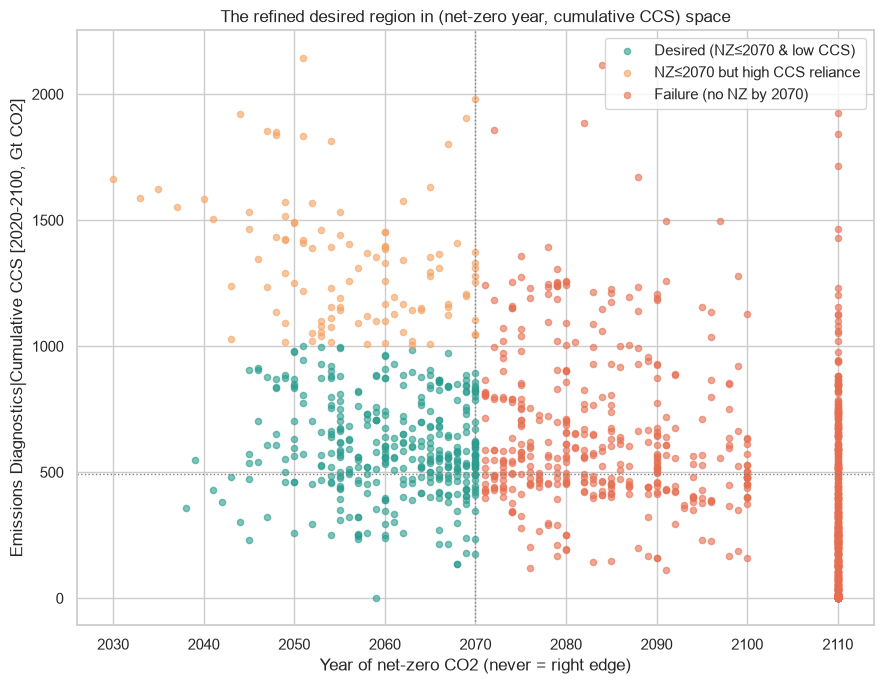

In [7]:
NZ_COL = "Emissions Diagnostics|Year of Net Zero|CO2"
CCS_COL = "Emissions Diagnostics|Cumulative CCS [2020-2100, Gt CO2]"
ccs_median = df[CCS_COL].median()

# scenarios that never reach net zero get plotted past the right edge, clearly separated
nz_plot_year = df[NZ_COL].fillna(df[NZ_COL].max() + 10)

fig, ax = plt.subplots(figsize=(9, 7))
for cat, color in CAT_PALETTE.items():
    mask = df["category"] == cat
    ax.scatter(nz_plot_year[mask], df.loc[mask, CCS_COL], color=color, label=cat, alpha=0.6, s=20)

ax.axvline(2070, color="grey", linewidth=1, linestyle=":")
ax.axhline(ccs_median, color="grey", linewidth=1, linestyle=":")
ax.set_xlabel("Year of net-zero CO2 (never = right edge)")
ax.set_ylabel(f"{CCS_COL}")
ax.set_title("The refined desired region in (net-zero year, cumulative CCS) space")
ax.legend()
fig.tight_layout()
plt.savefig("desired_region_scatter.png", dpi=150)
plt.show()

## Do "Desired" and "NZ but high CCS" scenarios differ on the other pathway variables?

If the desired group looks the same as the high-CCS group on, say, fossil decline or
electrification, that would suggest CCS reliance is mostly orthogonal to those levers. If they
look different, it suggests the desired pathways also mitigate harder elsewhere - not just
swapping CCS for nothing.

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/56475564.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/56475564.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/56475564.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh

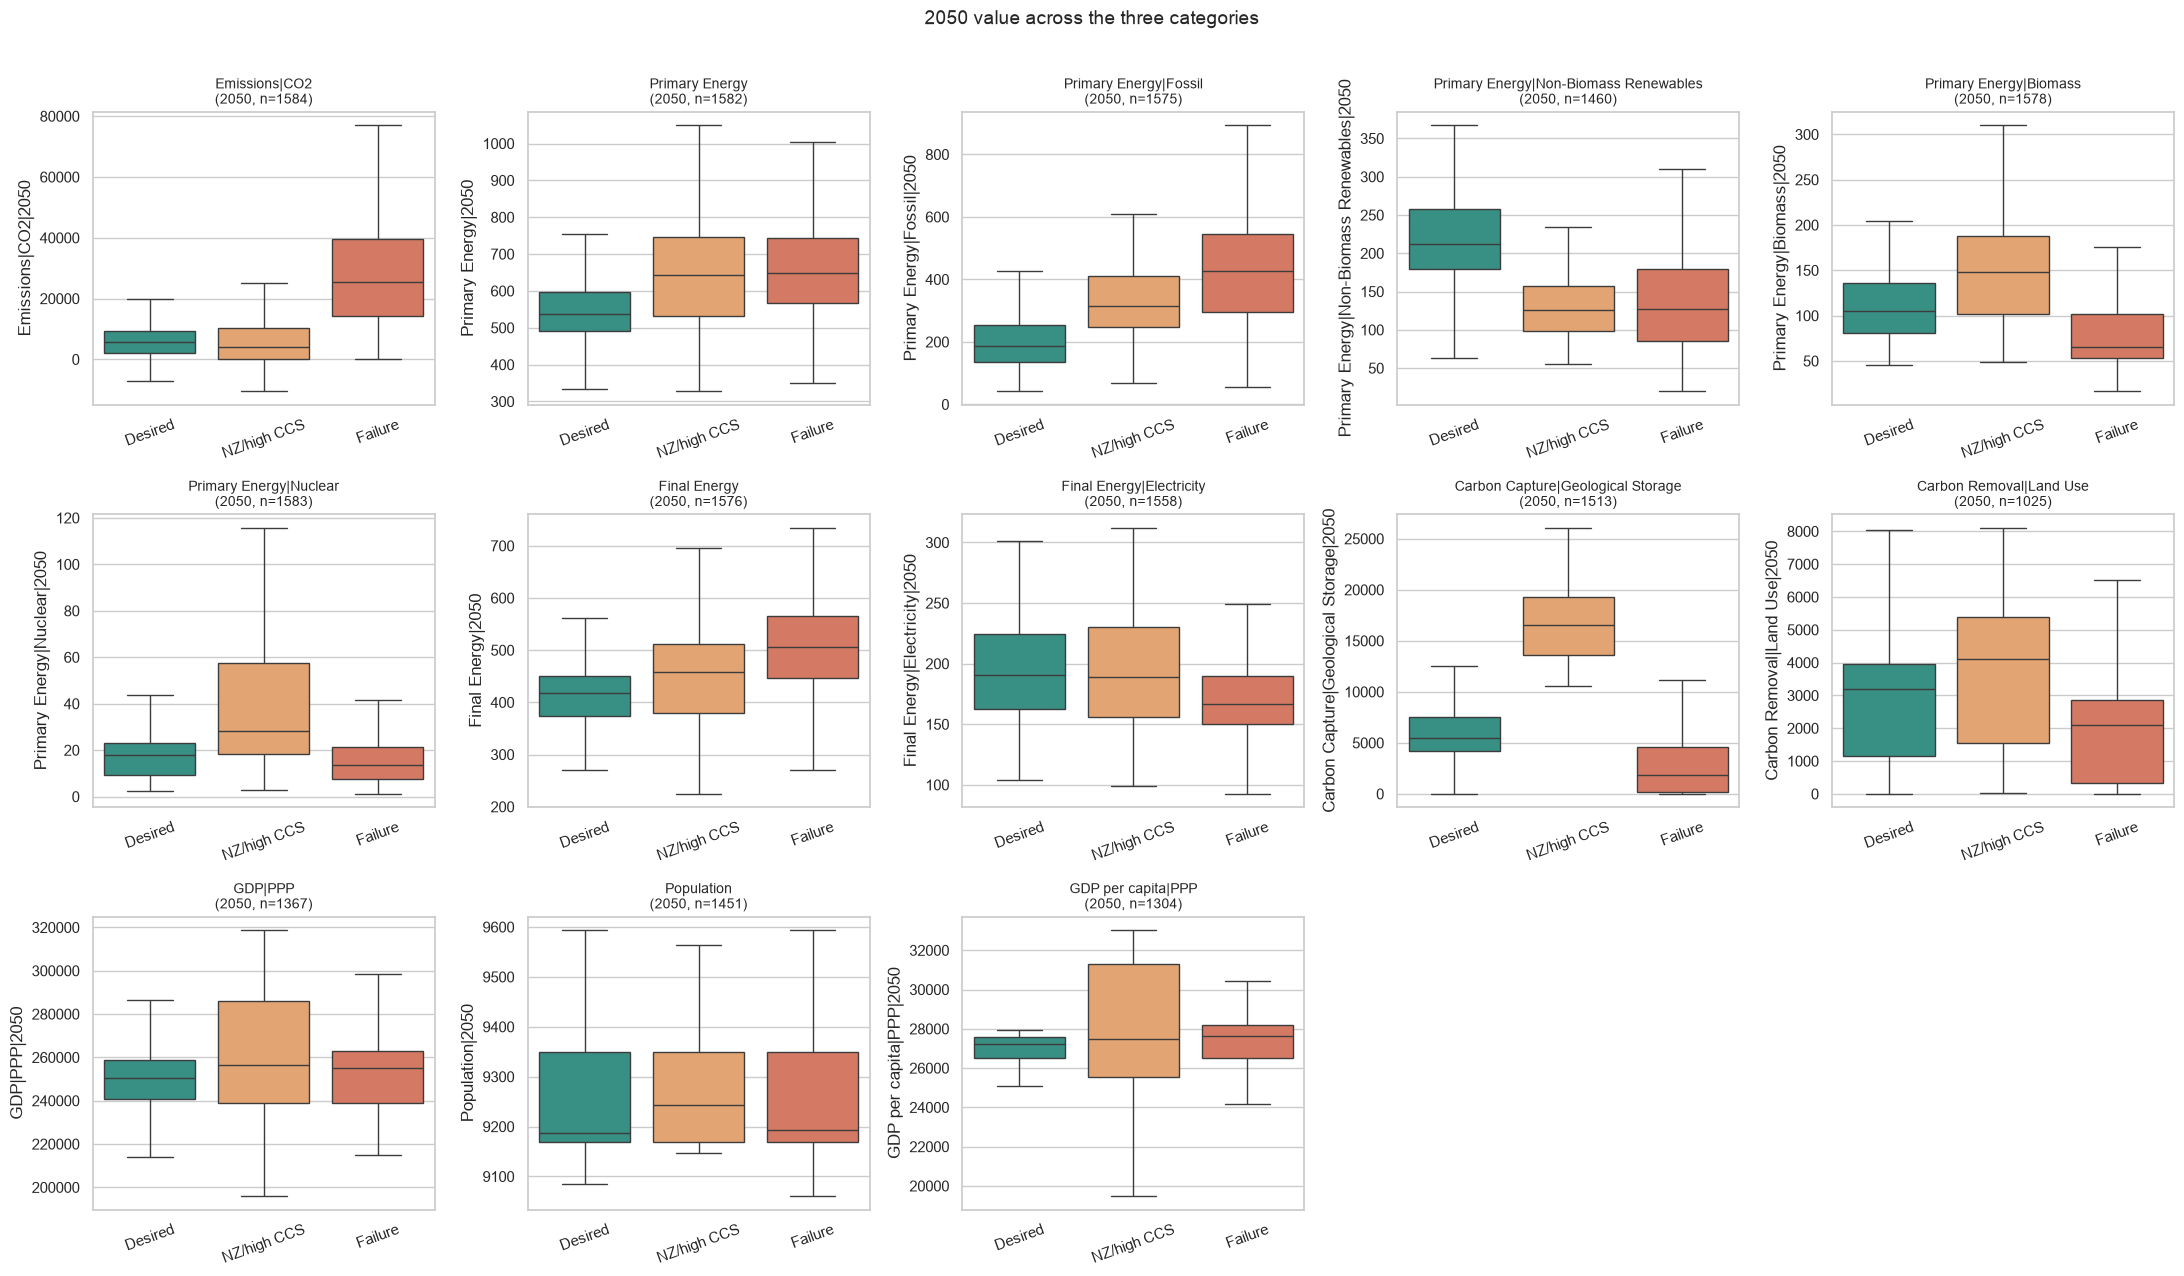

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for ax, var in zip(axes, VARS_OF_INTEREST):
    col = f"{var}|{SNAPSHOT_YEAR}"
    n_obs = df[col].notna().sum()
    sns.boxplot(
        data=df, x="category", y=col, hue="category", palette=CAT_PALETTE, ax=ax, legend=False,
        showfliers=False, order=list(CAT_PALETTE),
    )
    ax.set_title(f"{var}\n({SNAPSHOT_YEAR}, n={n_obs})", fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)
for ax in axes[len(VARS_OF_INTEREST):]:
    ax.set_visible(False)

fig.suptitle(f"{SNAPSHOT_YEAR} value across the three categories", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("boxplots_2050_threeway.png", dpi=150)
plt.show()

## Same comparison as distributions (histogram + KDE), three categories

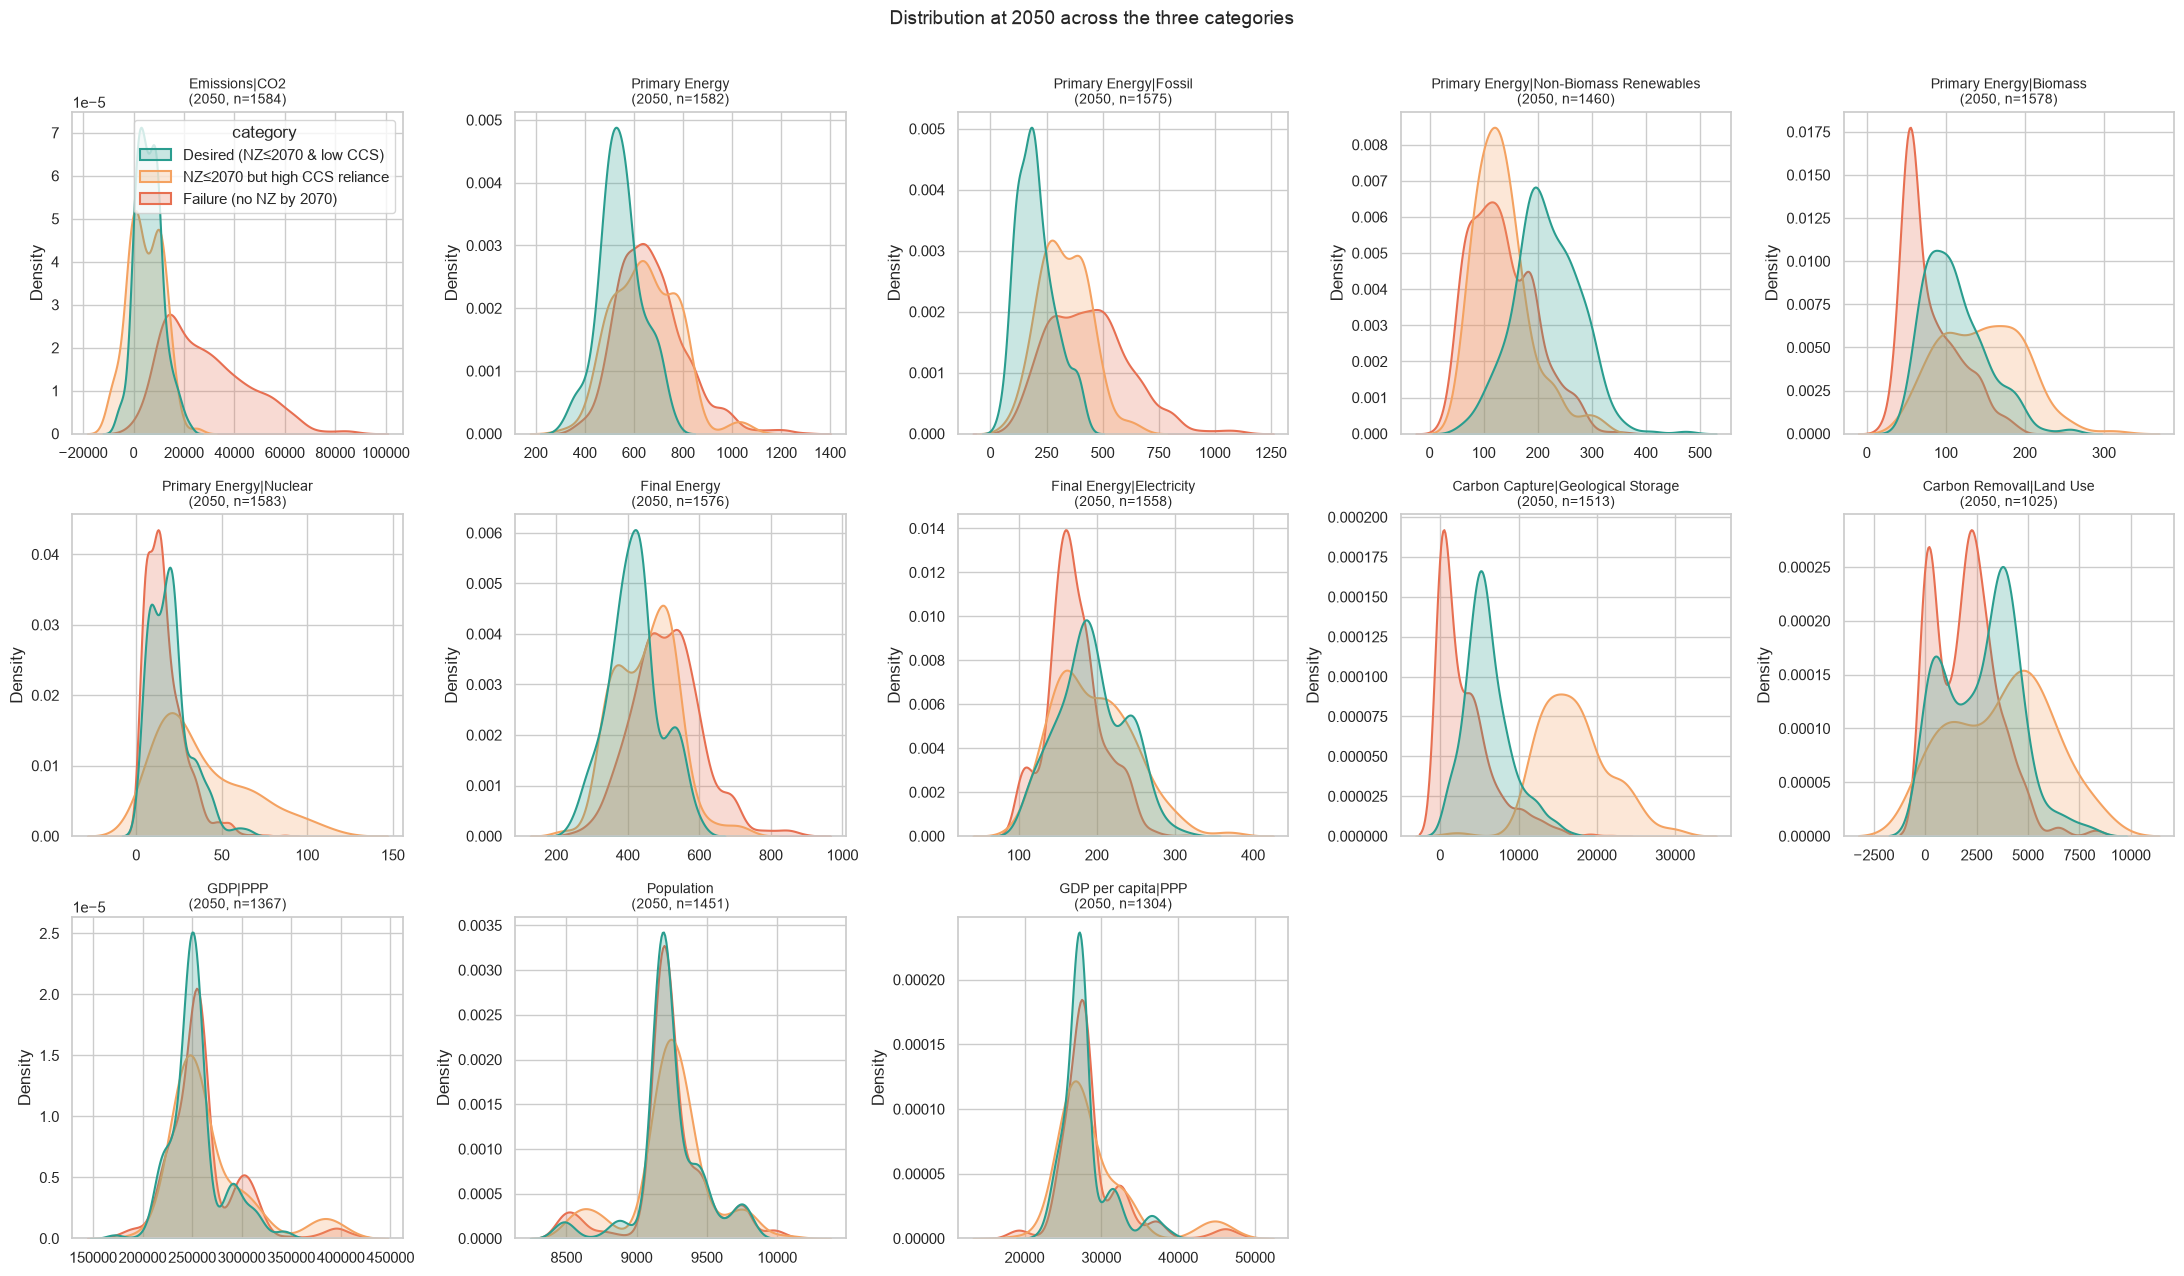

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for ax, var in zip(axes, VARS_OF_INTEREST):
    col = f"{var}|{SNAPSHOT_YEAR}"
    n_obs = df[col].notna().sum()
    sns.kdeplot(
        data=df, x=col, hue="category", palette=CAT_PALETTE, common_norm=False,
        fill=True, alpha=0.25, linewidth=1.5, ax=ax, legend=(var == VARS_OF_INTEREST[0]),
        hue_order=list(CAT_PALETTE),
    )
    ax.set_title(f"{var}\n({SNAPSHOT_YEAR}, n={n_obs})", fontsize=10)
    ax.set_xlabel("")
for ax in axes[len(VARS_OF_INTEREST):]:
    ax.set_visible(False)

fig.suptitle(f"Distribution at {SNAPSHOT_YEAR} across the three categories", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("distributions_2050_threeway.png", dpi=150)
plt.show()

## Ramp-up pace: progressive build-out vs late intensive ramp-up

`late_growth_share` (built in the pipeline step) is the fraction of a technology's 2020-2060 growth
that happens in 2040-2060 rather than 2020-2040. Values above ~0.6 mean the scenario leans on a late,
steep ramp-up; below ~0.4 means most of the build-out already happened early. Computed for the four
technologies most relevant to "ramp-up reliance": non-biomass renewables, electrification, nuclear,
and CCS.

/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/2136111423.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/2136111423.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gsccktxh/T/ipykernel_39708/2136111423.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)
/var/folders/v3/4pqc4lvj549b6fzgcxpbq9gs

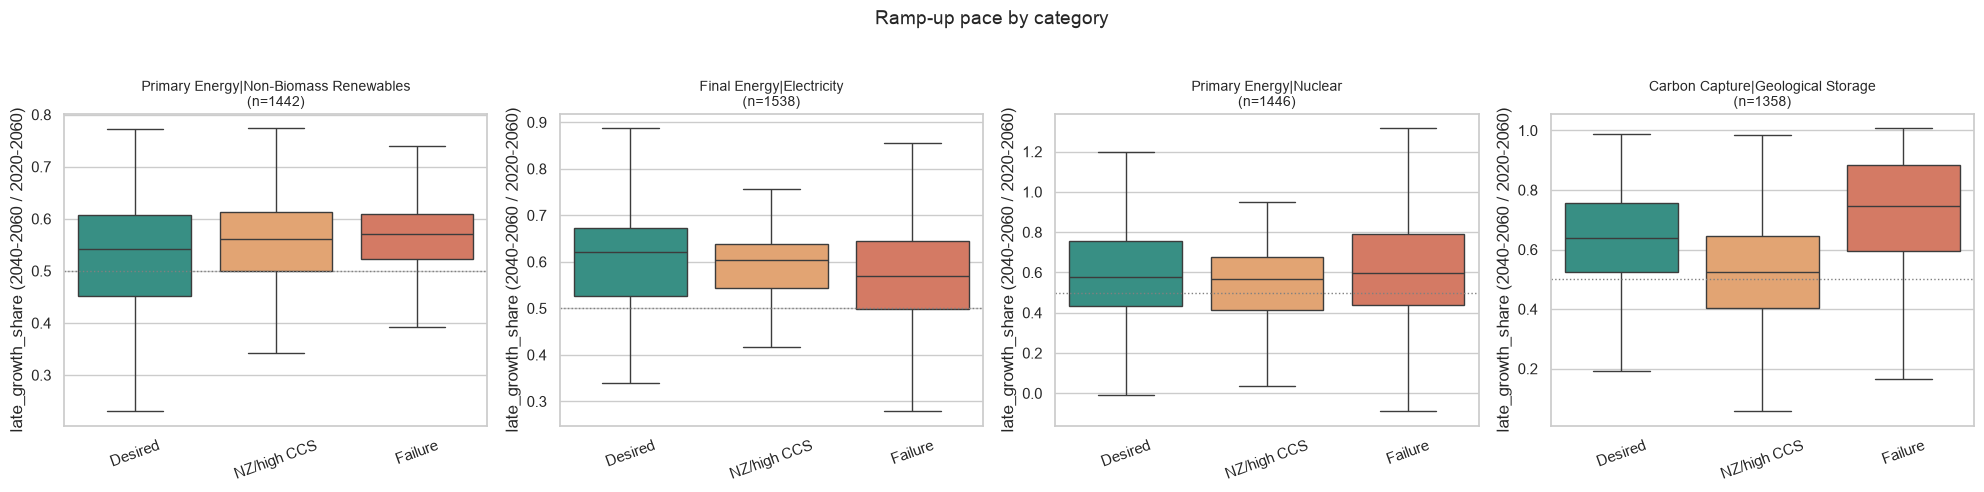

In [10]:
RAMP_VARS = [
    "Primary Energy|Non-Biomass Renewables",
    "Final Energy|Electricity",
    "Primary Energy|Nuclear",
    "Carbon Capture|Geological Storage",
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, var in zip(axes, RAMP_VARS):
    col = f"{var}|late_growth_share"
    n_obs = df[col].notna().sum()
    sns.boxplot(
        data=df, x="category", y=col, hue="category", palette=CAT_PALETTE, ax=ax, legend=False,
        showfliers=False, order=list(CAT_PALETTE),
    )
    ax.axhline(0.5, color="grey", linewidth=1, linestyle=":")
    ax.set_title(f"{var}\n(n={n_obs})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("late_growth_share (2040-2060 / 2020-2060)")
    ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)

fig.suptitle("Ramp-up pace by category", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("ramp_pace_threeway.png", dpi=150)
plt.show()

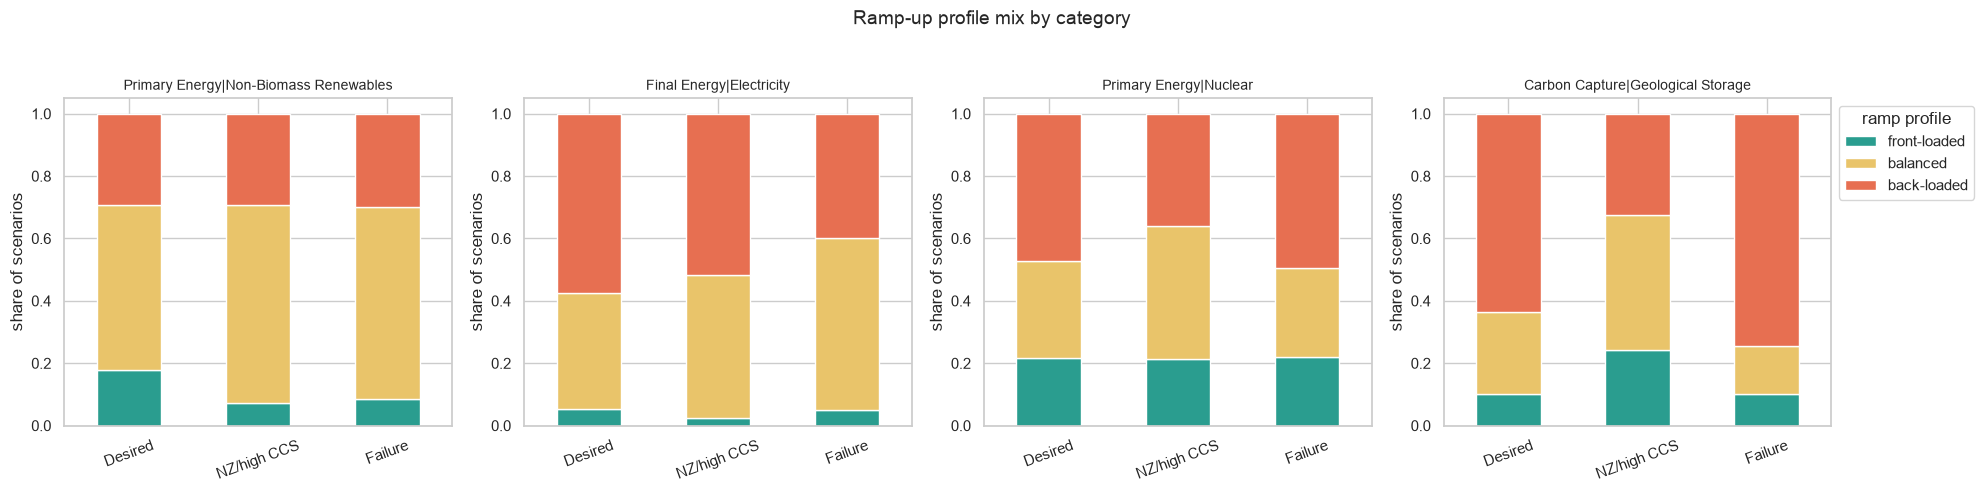

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, var in zip(axes, RAMP_VARS):
    col = f"{var}|ramp_profile"
    ct = pd.crosstab(df["category"], df[col], normalize="index").reindex(list(CAT_PALETTE))
    ct = ct[["front-loaded", "balanced", "back-loaded"]]
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#2a9d8f", "#e9c46a", "#e76f51"], legend=False)
    ax.set_title(var, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("share of scenarios")
    ax.set_xticklabels(["Desired", "NZ/high CCS", "Failure"], rotation=20)

axes[-1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), title="ramp profile")
fig.suptitle("Ramp-up profile mix by category", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("ramp_profile_mix_threeway.png", dpi=150)
plt.show()